In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

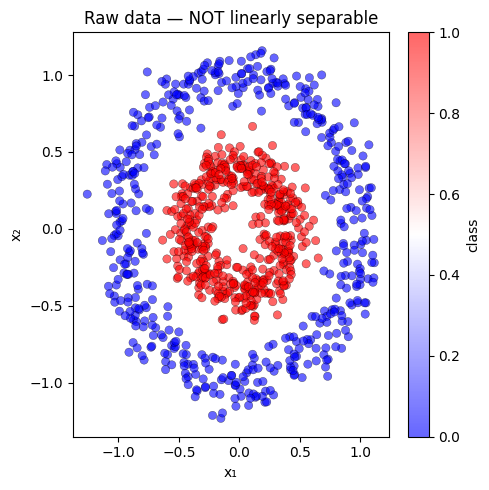

In [ ]:
X, y = make_circles(n_samples=1000, noise=0.1, factor=0.4, random_state=42)

fig, ax = plt.subplots(figsize=(5, 5))
sc = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.6, edgecolors='k', linewidths=0.3)
ax.set_title('Raw data — NOT linearly separable')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
plt.colorbar(sc, ax=ax, label='class')
plt.tight_layout()
plt.show()



In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr_raw = LogisticRegression()
lr_raw.fit(X_scaled, y)
acc_raw = lr_raw.score(X_scaled, y)

r_sq = (X[:, 0]**2 + X[:, 1]**2).reshape(-1, 1)
lr_oracle = LogisticRegression()
lr_oracle.fit(r_sq, y)
acc_oracle = lr_oracle.score(r_sq, y)

print(f'LR on raw (x₁, x₂):       accuracy = {acc_raw:.2%}')
print(f'LR on φ(x) = r²  (oracle): accuracy = {acc_oracle:.2%}')

LR on raw (x₁, x₂):       accuracy = 50.20%
LR on φ(x) = r²  (oracle): accuracy = 99.90%


/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a

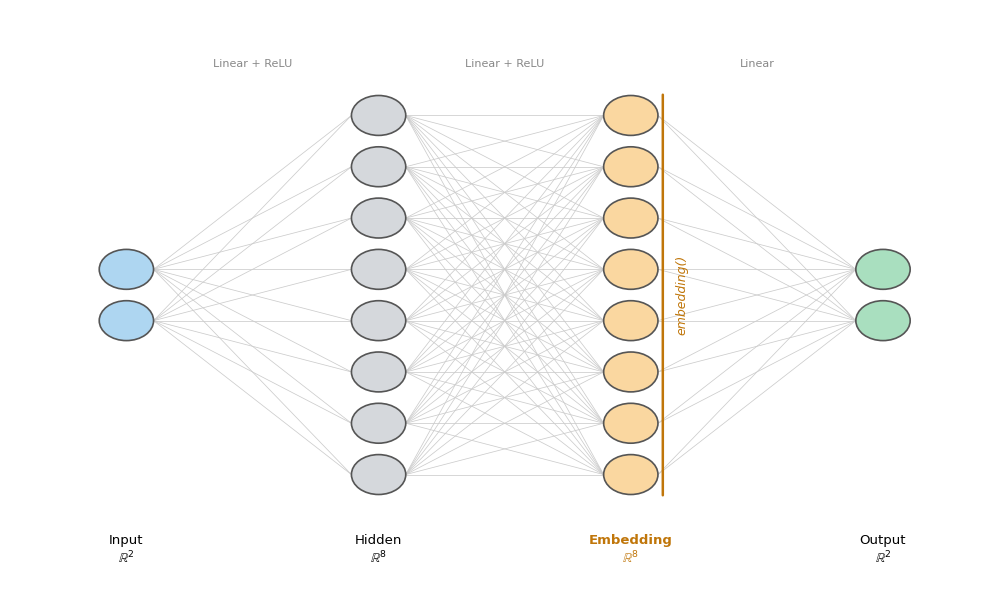

In [9]:
import matplotlib.pyplot as plt

def draw_nn_architecture():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlim(0, 10)
    ax.set_ylim(-1, 7)
    ax.axis('off')

    colors = {'input': '#AED6F1', 'hidden': '#D5D8DC',
              'embed': '#FAD7A0', 'output': '#A9DFBF'}

    # (x, n_neurons, type)
    layers = [
        (1.2, 2, 'input'),
        (3.8, 8, 'hidden'),
        (6.4, 8, 'embed'),
        (9.0, 2, 'output'),
    ]
    layer_labels = ['Input\n$\\mathbb{R}^{2}$',
                    'Hidden\n$\\mathbb{R}^{8}$',
                    'Embedding\n$\\mathbb{R}^{8}$',
                    'Output\n$\\mathbb{R}^{2}$']
    act_labels = ['Linear + ReLU', 'Linear + ReLU', 'Linear']

    r = 0.28

    def neuron_ys(n):
        spacing = 0.72
        return [3.0 + (i - (n - 1) / 2) * spacing for i in range(n)]

    layer_centers = [(x, neuron_ys(n), ltype) for x, n, ltype in layers]

    # Connections
    for i in range(len(layer_centers) - 1):
        x1, ys1, _ = layer_centers[i]
        x2, ys2, _ = layer_centers[i + 1]
        for y1 in ys1:
            for y2 in ys2:
                ax.plot([x1 + r, x2 - r], [y1, y2],
                        color='#CCCCCC', linewidth=0.55, zorder=1)

    # Neurons
    for (x, ys, ltype) in layer_centers:
        for y in ys:
            ax.add_patch(plt.Circle((x, y), r, color=colors[ltype],
                                    ec='#555555', linewidth=1.2, zorder=2))

    # Layer labels
    for idx, (x, ys, ltype) in enumerate(layer_centers):
        col = '#C0760A' if ltype == 'embed' else 'black'
        fw = 'bold' if ltype == 'embed' else 'normal'
        ax.text(x, -0.35, layer_labels[idx], ha='center', va='top',
                fontsize=9.5, fontweight=fw, color=col, multialignment='center')

    # Activation labels
    for i in range(len(layer_centers) - 1):
        x1, x2 = layer_centers[i][0], layer_centers[i + 1][0]
        ax.text((x1 + x2) / 2, 6.2, act_labels[i], ha='center',
                fontsize=8, color='#888888', multialignment='center')

    # embedding() annotation
    ex = layer_centers[2][0]
    eys = layer_centers[2][1]
    y_top, y_bot = max(eys) + r + 0.05, min(eys) - r - 0.05
    ax.annotate('', xy=(ex + r + 0.05, y_bot), xytext=(ex + r + 0.05, y_top),
                arrowprops=dict(arrowstyle='-', color='#C0760A', lw=1.8))
    ax.text(ex + r + 0.18, (y_top + y_bot) / 2, 'embedding()',
            ha='left', va='center', fontsize=9,
            color='#C0760A', fontstyle='italic', rotation=90)

    plt.tight_layout()
    plt.show()

draw_nn_architecture()

In [10]:
class MLP(nn.Module):
    def __init__(self, embed_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, embed_dim),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(embed_dim, 2)

    def embedding(self, x):
        return self.encoder(x)

    def forward(self, x):
        return self.classifier(self.embedding(x))

Neural network accuracy: 100.00%


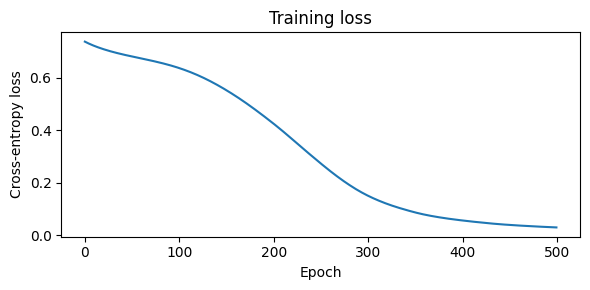

In [11]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

model = MLP(embed_dim=16)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

losses = []
for epoch in range(500):
    model.train()
    optimizer.zero_grad()
    loss = criterion(model(X_tensor), y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

model.eval()
with torch.no_grad():
    acc_nn = (model(X_tensor).argmax(dim=1) == y_tensor).float().mean().item()

print(f'Neural network accuracy: {acc_nn:.2%}')

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Training loss')
plt.tight_layout()
plt.show()

/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/kevalamin/Documents/stat154/lab_11/stat254

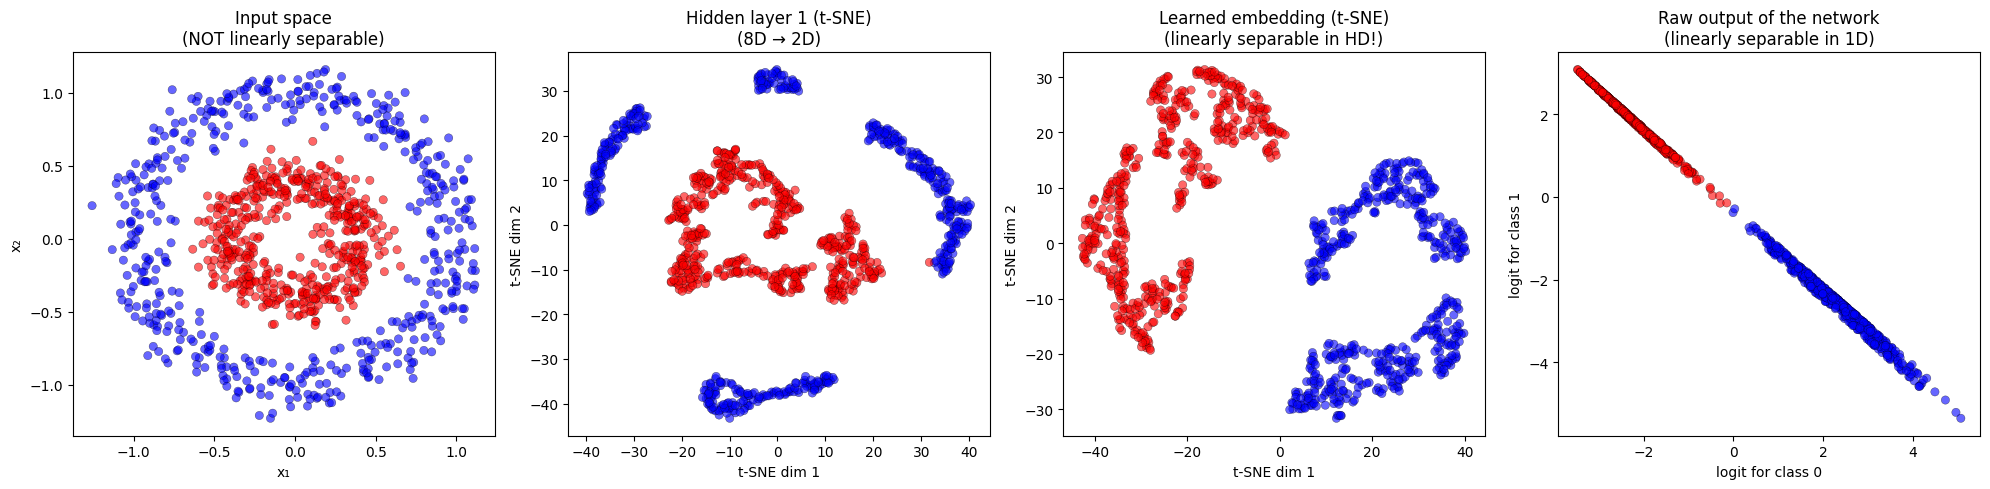

In [12]:
model.eval()
with torch.no_grad():
    raw_Z = model.forward(X_tensor).numpy()          # shape: (1000, 2)
    Z = model.embedding(X_tensor).numpy()            # shape: (1000, 16)
    H = model.encoder[:2](X_tensor).numpy()          # shape: (1000, 8)  — first hidden layer (Linear + ReLU)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
Z_2d = tsne.fit_transform(Z)

tsne_h = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
H_2d = tsne_h.fit_transform(H)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.6, edgecolors='k', linewidths=0.3)
axes[0].set_title('Input space\n(NOT linearly separable)')
axes[0].set_xlabel('x₁')
axes[0].set_ylabel('x₂')

axes[1].scatter(H_2d[:, 0], H_2d[:, 1], c=y, cmap='bwr', alpha=0.6, edgecolors='k', linewidths=0.3)
axes[1].set_title('Hidden layer 1 (t-SNE)\n(8D → 2D)')
axes[1].set_xlabel('t-SNE dim 1')
axes[1].set_ylabel('t-SNE dim 2')

axes[2].scatter(Z_2d[:, 0], Z_2d[:, 1], c=y, cmap='bwr', alpha=0.6, edgecolors='k', linewidths=0.3)
axes[2].set_title('Learned embedding (t-SNE)\n(linearly separable in HD!)')
axes[2].set_xlabel('t-SNE dim 1')
axes[2].set_ylabel('t-SNE dim 2')

axes[3].scatter(raw_Z[:, 0], raw_Z[:, 1], c=y, cmap='bwr', alpha=0.6, edgecolors='k', linewidths=0.3)
axes[3].set_title('Raw output of the network\n(linearly separable in 1D)')
axes[3].set_xlabel('logit for class 0')
axes[3].set_ylabel('logit for class 1')

plt.tight_layout()
plt.show()

In [13]:
lr_embed = LogisticRegression()
lr_embed.fit(Z, y)
acc_embed = lr_embed.score(Z, y)

print('Logistic regression accuracy:')
print(f'  Raw (x₁, x₂):       {acc_raw:.2%}')
print(f'  φ(x) = r² (oracle): {acc_oracle:.2%}')
print(f'  NN embedding:        {acc_embed:.2%}')
print()
print('The NN discovered a representation as good as the hand-crafted oracle feature.')

Logistic regression accuracy:
  Raw (x₁, x₂):       50.20%
  φ(x) = r² (oracle): 99.90%
  NN embedding:        100.00%

The NN discovered a representation as good as the hand-crafted oracle feature.


/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/kevalamin/Documents/stat154/lab_11/stat254-env/lib/python3.9/site-packages/sklearn/linear_mo

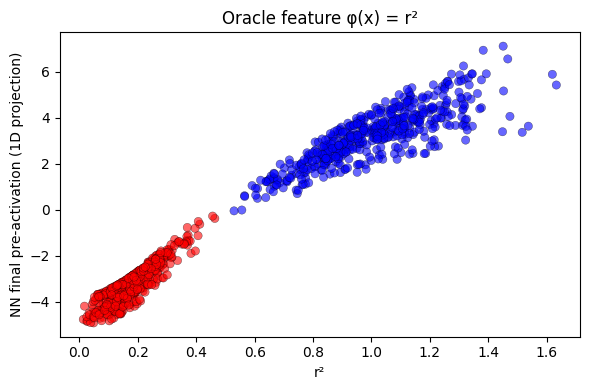

In [14]:
from sklearn.decomposition import PCA

raw_Z_pc1 = PCA(n_components=1).fit_transform(raw_Z)

rs = X[:, 0]**2 + X[:, 1]**2
plt.figure(figsize=(6, 4))
plt.scatter(rs, raw_Z_pc1, c=y, cmap='bwr', alpha=0.6, edgecolors='k', linewidths=0.3)
plt.title('Oracle feature φ(x) = r²')
plt.xlabel('r²')
plt.ylabel('NN final pre-activation (1D projection)')
plt.tight_layout()
plt.show()